# ✈️ DelayPredict — 03a Random Forest (Target Encoding)

**Goal:** Train a high-quality Random Forest using Target Encoding — replacing high-cardinality
categorical features with their historical delay rates. This gives RF clean numeric signals
instead of hundreds of sparse binary columns.

**Key improvements over naive OHE approach:**
- `Airline`, `AirportFrom`, `AirportTo` → encoded as their historical delay rate (0.0–1.0)
- `Route` (AirportFrom + AirportTo) → new feature, target encoded — captures route-level delay patterns
- RF works with ~10 clean numeric features instead of 610 sparse binary columns

---
**Input:** `data/raw/airlines_delay.csv`  
**Input (optional):** `data/processed/baseline_metrics.csv`  
**Output:** `models/rf_model.pkl`, `data/processed/rf_metrics.csv`  
**MLflow:** Run is logged automatically at the end of this notebook

## 1. Setup and Imports

In [250]:
# Install dependencies if not already present
import subprocess
subprocess.run(["pip", "install", "mlflow"], check=True)


CompletedProcess(args=['pip', 'install', 'mlflow'], returncode=0)

In [251]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

import joblib
import mlflow
import mlflow.sklearn

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42  # fixed seed for reproducibility


## 2. Load Raw Data

Always loads from the **raw dataset** — fully self-contained, no dependency on other notebooks.

In [252]:
RAW_PATH = Path("../data/raw/airlines_delay.csv")

if not RAW_PATH.exists():
    raise FileNotFoundError(
        f"Raw dataset not found at {RAW_PATH}.\n"
        "Please place airlines_delay.csv in data/raw/"
    )

df = pd.read_csv(RAW_PATH)

print("Source :", RAW_PATH)
print("Shape  :", df.shape)
display(df.head())


Source : ..\data\raw\airlines_delay.csv
Shape  : (539383, 9)


,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3,15,205,1
1,2,US,1558,PHX,CLT,3,15,222,1
2,3,AA,2400,LAX,DFW,3,20,165,1
3,4,AA,2466,SFO,DFW,3,20,195,1
4,5,AS,108,ANC,SEA,3,30,202,0


## 3. Feature Engineering

Two transformations applied from raw data:

| Step | Action | Reason |
|---|---|---|
| `Time` → `DepartureHour` | `Time // 60` | Time is minutes since midnight (0–1439) |
| `Route` | `AirportFrom + '-' + AirportTo` | Captures combined origin-destination delay pattern |

`Route` is a powerful feature — a specific airport pair (e.g. MDW→SFO) has a much more
predictable delay pattern than either airport individually.

In [253]:
# ── Derive DepartureHour from Time ──────────────────────────────────────────
# Time is stored as minutes since midnight (0 = 00:00, 1439 = 23:59)
df["DepartureHour"] = df["Time"] // 60

# ── Create Route feature ─────────────────────────────────────────────────────
# Combines origin and destination into a single route identifier
# e.g. 'SFO-IAH', 'LAX-DFW' — will be target-encoded as its delay rate
df["Route"] = df["AirportFrom"] + "-" + df["AirportTo"]

# ── Drop columns not used for modeling ──────────────────────────────────────
DROP_COLS = ["id", "Flight", "Time"]
df = df.drop(columns=DROP_COLS)

print("Columns after feature engineering:", df.columns.tolist())
print("Shape:", df.shape)
display(df.head())


Columns after feature engineering: ['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Length', 'Delay', 'DepartureHour', 'Route']
Shape: (539383, 8)


,Airline,AirportFrom,AirportTo,DayOfWeek,Length,Delay,DepartureHour,Route
0,CO,SFO,IAH,3,205,1,0,SFO-IAH
1,US,PHX,CLT,3,222,1,0,PHX-CLT
2,AA,LAX,DFW,3,165,1,0,LAX-DFW
3,AA,SFO,DFW,3,195,1,0,SFO-DFW
4,AS,ANC,SEA,3,202,0,0,ANC-SEA


## 4. Features and Target

**Target:** `Delay` — 1 if the flight arrived more than 15 minutes late, 0 otherwise.

In [254]:
TARGET = "Delay"

X = df.drop(columns=[TARGET])  # feature matrix
y = df[TARGET]                  # target vector (0 = no delay, 1 = delay)

print("Features:", X.columns.tolist())
print("X shape :", X.shape)
print()

dist = y.value_counts(normalize=True).mul(100).round(1).rename("% share")
print("Target distribution:")
display(dist)


Features: ['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Length', 'DepartureHour', 'Route']
X shape : (539383, 7)

Target distribution:


Delay
0    55.5
1    44.5
Name: % share, dtype: float64

## 5. Feature Types

**Core idea:** instead of exploding high-cardinality categoricals into hundreds of binary columns,
we encode them as a single number — their historical delay rate.

| Feature | Cardinality | Encoding | Result |
|---|---|---|---|
| Airline | 18 | TargetEncoder | 1 numeric column (delay rate per airline) |
| AirportFrom | 293 | TargetEncoder | 1 numeric column (delay rate per origin) |
| AirportTo | 293 | TargetEncoder | 1 numeric column (delay rate per destination) |
| Route | ~2000 | TargetEncoder | 1 numeric column (delay rate per route) |
| DayOfWeek | numeric | passthrough | 1 column |
| Length | numeric | passthrough | 1 column |
| DepartureHour | numeric | passthrough | 1 column |

**Total: ~13 features** vs. 610 with full OHE — RF can now split meaningfully on every feature.

In [255]:
# Features encoded with TargetEncoder (high cardinality → 1 numeric column each)
TARGET_ENC_FEATURES = ["Airline", "AirportFrom", "AirportTo", "Route"]

# Numeric features — passed through unchanged
NUMERIC = ["Length", "DepartureHour", "DayOfWeek"]

# All categoricals (for assertion check)
ALL_CATEGORICALS = TARGET_ENC_FEATURES 

assert all(f in X.columns for f in ALL_CATEGORICALS + NUMERIC), \
    "Feature mismatch — check dataset columns."

print("Target-encoded :", TARGET_ENC_FEATURES)
print("OHE            :", OHE_FEATURES)
print("Numeric        :", NUMERIC)


Target-encoded : ['Airline', 'AirportFrom', 'AirportTo', 'Route']
OHE            : ['DayOfWeek']
Numeric        : ['Length', 'DepartureHour', 'DayOfWeek']


## 6. Train / Test Split

**Split must happen before any encoding** — the TargetEncoder will fit on training data only.
This is enforced automatically by placing it inside the sklearn Pipeline.

- **80 / 20** split — same ratio as all other notebooks for fair comparison
- `stratify=y` — preserves class ratio in both splits
- `random_state=42` — same seed as all notebooks for identical splits

In [256]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {X_train.shape}  |  delay rate: {y_train.mean():.3f}")
print(f"Test : {X_test.shape}   |  delay rate: {y_test.mean():.3f}")


Train: (431506, 7)  |  delay rate: 0.445
Test : (107877, 7)   |  delay rate: 0.445


## 7. Preprocessing Pipeline

`TargetEncoder` replaces each category with its smoothed historical delay rate,
computed via cross-fitting on the training set to prevent leakage.

The smoothing parameter balances between the category's own rate and the global mean —
rare categories (few flights) are pulled toward the global average.

In [257]:
# Combines numeric features (passthrough) and target-encoded categoricals
# into a single feature matrix for the model.

preprocessor = ColumnTransformer(
    transformers=[
        # Numeric features: passthrough — RF is scale-invariant
        ("num", "passthrough", NUMERIC),

        # High-cardinality categoricals: encode as historical delay rate
        # smooth='auto' balances category rate vs. global mean for rare categories
        ("target_enc", TargetEncoder(smooth="auto", random_state=RANDOM_STATE),
         TARGET_ENC_FEATURES),

    ],
    remainder="drop",
)


## 8. Random Forest Model

With clean numeric features from Target Encoding, RF can now learn effectively.

**Hyperparameter choices:**

| Parameter | Value | Reason |
|---|---|---|
| `n_estimators` | 300 | More trees = more stable predictions. 100 is too few for this dataset. |
| `max_depth` | 20 | Prevents overfitting — trees don't need to grow fully with good features |
| `min_samples_leaf` | 20 | Each leaf must represent at least 20 flights — reduces noise |
| `max_features` | `'sqrt'` | Standard for classification — reduces correlation between trees |
| `class_weight` | None | 55/45 split is mild |
| `n_jobs` | -1 | Use all CPU cores |

In [258]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,      # more trees → more stable, diminishing returns above ~300
        max_depth=20,          # limits tree depth to avoid overfitting on noisy splits
        min_samples_leaf=20,   # each leaf needs at least 20 samples — smooths predictions
        max_features="sqrt",   # consider sqrt(n_features) per split — reduces tree correlation
        class_weight=None,     # no reweighting — 55/45 is mild imbalance
        n_jobs=-1,             # use all CPU cores for parallel tree building
        random_state=RANDOM_STATE,
    )),
])

rf_pipeline.fit(X_train, y_train)
print("Random Forest trained successfully.")


Random Forest trained successfully.


## 9. Evaluate

Evaluate on the held-out test set — no target encoding information from test set was used during training.

Evaluation metrics:
1. Accuracy  — share of correct predictions overall
2. Precision — of all predicted delays, how many were actual delays
3. Recall    — of all actual delays, how many did we catch
4. F1        — harmonic mean of Precision and Recall
5. ROC-AUC   — ability to rank delayed flights above non-delayed ones (0.5 = random, 1.0 = perfect)

In [259]:
y_pred_rf  = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

rf_metrics = {
    "Accuracy" : accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf, zero_division=0),
    "Recall"   : recall_score(y_test, y_pred_rf, zero_division=0),
    "F1"       : f1_score(y_test, y_pred_rf, zero_division=0),
    "ROC-AUC"  : roc_auc_score(y_test, y_proba_rf),
}

print("Random Forest metrics:")
for k, v in rf_metrics.items():
    print(f"  {k:<10}: {v:.4f}")

print()
print(classification_report(
    y_test, y_pred_rf,
    target_names=["No Delay", "Delay"],
    zero_division=0
))


Random Forest metrics:
  Accuracy  : 0.6677
  Precision : 0.6707
  Recall    : 0.4990
  F1        : 0.5722
  ROC-AUC   : 0.7205

              precision    recall  f1-score   support

    No Delay       0.67      0.80      0.73     59824
       Delay       0.67      0.50      0.57     48053

    accuracy                           0.67    107877
   macro avg       0.67      0.65      0.65    107877
weighted avg       0.67      0.67      0.66    107877



## 10. Comparison Against Baseline

Load baseline metrics from `02_baseline.ipynb` and compare.

In [260]:
BASELINE_METRICS_PATH = Path("../data/processed/baseline_metrics.csv")

rf_row = {"model": "RandomForest", **rf_metrics}

if BASELINE_METRICS_PATH.exists():
    comparison_df = pd.read_csv(BASELINE_METRICS_PATH)
    comparison_df = pd.concat(
        [comparison_df, pd.DataFrame([rf_row])],
        ignore_index=True
    )
else:
    print("baseline_metrics.csv not found — run 02_baseline.ipynb for full comparison.")
    comparison_df = pd.DataFrame([rf_row])

display(comparison_df.round(4))


,model,Accuracy,Precision,Recall,F1,ROC-AUC
0,DummyClassifier,0.5546,0.0000,0.0000,0.0000,0.5000
1,LogisticRegression,0.6464,0.6345,0.4862,0.5506,0.6921
2,RandomForest,0.6677,0.6707,0.4990,0.5722,0.7205


## 11. Confusion Matrix

- **True Negatives (top-left):** correctly predicted No Delay
- **False Positives (top-right):** predicted Delay, actually No Delay
- **False Negatives (bottom-left):** predicted No Delay, actually Delay ← the costly error
- **True Positives (bottom-right):** correctly predicted Delay

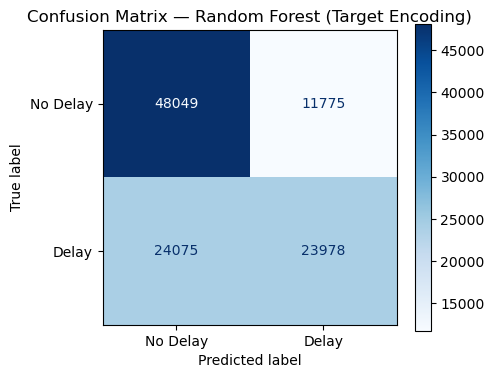

In [261]:
fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=["No Delay", "Delay"],
    cmap="Blues",
    ax=ax,
)
ax.set_title("Confusion Matrix — Random Forest (Target Encoding)")
plt.tight_layout()
plt.show()


## 12. ROC Curve and Precision-Recall Curve

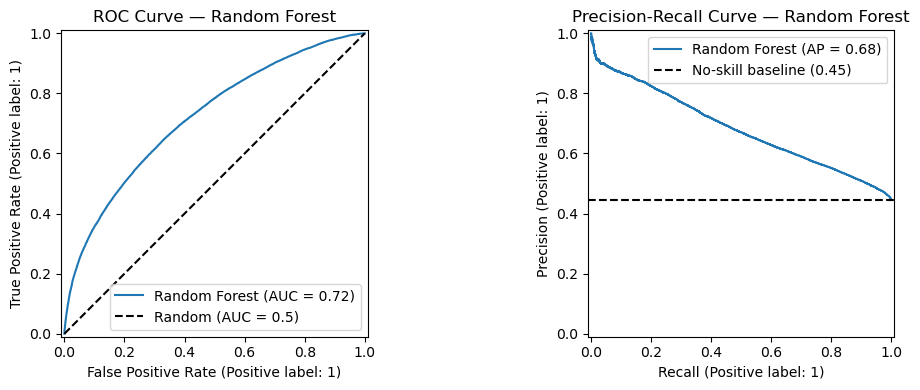

In [262]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

RocCurveDisplay.from_predictions(y_test, y_proba_rf, ax=ax1, name="Random Forest")
ax1.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
ax1.set_title("ROC Curve — Random Forest")
ax1.legend()

PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf, ax=ax2, name="Random Forest")
ax2.axhline(y_test.mean(), color="k", linestyle="--",
            label=f"No-skill baseline ({y_test.mean():.2f})")
ax2.set_title("Precision-Recall Curve — Random Forest")
ax2.legend()

plt.tight_layout()
plt.show()


## 13. Feature Importance

With Target Encoding, feature names are clean and directly interpretable —
no hundreds of `AirportFrom_ATL`, `AirportFrom_LAX` entries.

Feature importances:


,Feature,Importance
0,Route,0.245472
1,Airline,0.239370
2,DepartureHour,0.163172
3,AirportFrom,0.114052
4,AirportTo,0.103688
5,Length,0.088896
6,DayOfWeek,0.045349


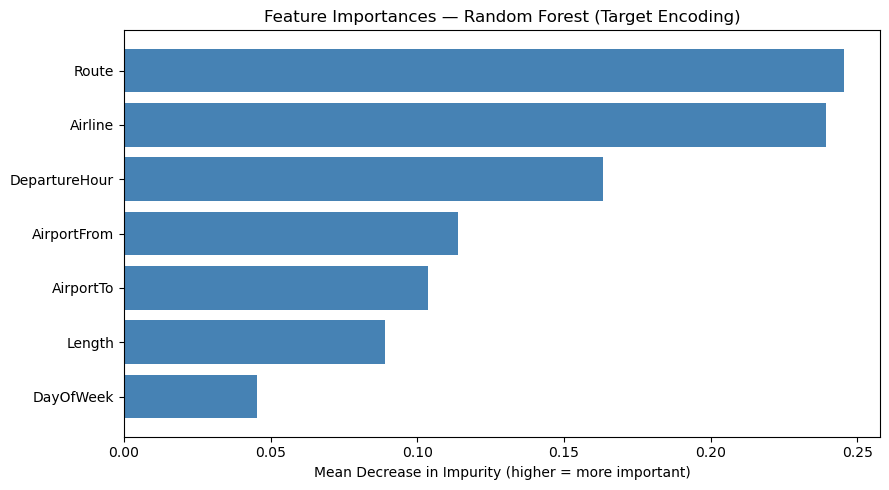

In [263]:
# ── Reconstruct feature names in ColumnTransformer output order ─────────────
# Order: numeric → target_enc → ohe (matches transformer order above)

feature_names = NUMERIC + TARGET_ENC_FEATURES
importances   = rf_pipeline.named_steps["classifier"].feature_importances_

importance_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("Feature importances:")
display(importance_df)

# ── Bar chart ────────────────────────────────────────────────────────────────
plot_df = importance_df.sort_values("Importance")

plt.figure(figsize=(9, 5))
plt.barh(plot_df["Feature"], plot_df["Importance"], color="steelblue")
plt.title("Feature Importances — Random Forest (Target Encoding)")
plt.xlabel("Mean Decrease in Impurity (higher = more important)")
plt.tight_layout()
plt.show()


## 14. Predicted Probability Distribution

A well-calibrated model pushes probabilities toward 0 and 1.  
With Target Encoding, RF should show better separation than with OHE.

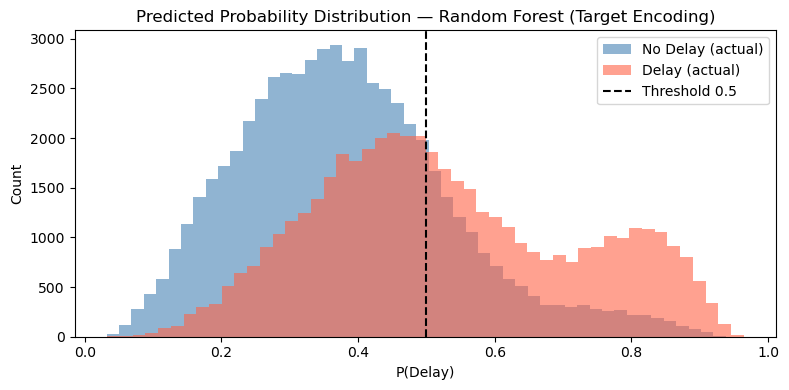

In [264]:
plt.figure(figsize=(8, 4))

plt.hist(y_proba_rf[y_test == 0], bins=50, alpha=0.6,
         label="No Delay (actual)", color="steelblue")
plt.hist(y_proba_rf[y_test == 1], bins=50, alpha=0.6,
         label="Delay (actual)", color="tomato")
plt.axvline(0.5, color="black", linestyle="--", label="Threshold 0.5")

plt.title("Predicted Probability Distribution — Random Forest (Target Encoding)")
plt.xlabel("P(Delay)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


## 15. Save Model and Metrics

In [265]:
# ── Save trained model ───────────────────────────────────────────────────────
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR / "rf_model.pkl"
joblib.dump(rf_pipeline, MODEL_PATH)
print(f"Model saved   : {MODEL_PATH}")

# ── Save RF metrics ───────────────────────────────────────────────────────────
OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

rf_metrics_df = pd.DataFrame([{"model": "RandomForest", **rf_metrics}])
RF_METRICS_PATH = OUTPUT_DIR / "rf_metrics.csv"
rf_metrics_df.to_csv(RF_METRICS_PATH, index=False)
print(f"Metrics saved : {RF_METRICS_PATH}")


Model saved   : ..\models\rf_model.pkl
Metrics saved : ..\data\processed\rf_metrics.csv


## 16. MLflow Logging

Logs this run to the shared `DelayPredict` experiment.  
Start the UI with `mlflow ui` → `http://localhost:5000`.

In [266]:
mlflow.set_experiment("DelayPredict")

with mlflow.start_run(run_name="RandomForest_TargetEncoding"):

    # ── Hyperparameters ──────────────────────────────────────────────────────
    rf_clf = rf_pipeline.named_steps["classifier"]
    mlflow.log_params({
        "model"            : "RandomForest",
        "encoding"         : "TargetEncoder",
        "n_estimators"     : rf_clf.n_estimators,
        "max_depth"        : str(rf_clf.max_depth),
        "min_samples_leaf" : rf_clf.min_samples_leaf,
        "max_features"     : rf_clf.max_features,
        "random_state"     : RANDOM_STATE,
        "train_size"       : X_train.shape[0],
        "test_size"        : X_test.shape[0],
        "features"         : ", ".join(TARGET_ENC_FEATURES + OHE_FEATURES + NUMERIC),
    })

    # ── Metrics ──────────────────────────────────────────────────────────────
    mlflow.log_metrics({
        "accuracy" : rf_metrics["Accuracy"],
        "precision": rf_metrics["Precision"],
        "recall"   : rf_metrics["Recall"],
        "f1"       : rf_metrics["F1"],
        "roc_auc"  : rf_metrics["ROC-AUC"],
    })

    # ── Model artifact ───────────────────────────────────────────────────────
    mlflow.sklearn.log_model(rf_pipeline, artifact_path="model")

    print("MLflow run logged — experiment: 'DelayPredict'")
    print("Run name: RandomForest_TargetEncoding")
    print("Start MLflow UI with: mlflow ui")


2026/04/20 21:06:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 21:06:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run logged — experiment: 'DelayPredict'
Run name: RandomForest_TargetEncoding
Start MLflow UI with: mlflow ui


## 17. Summary

In [267]:
print("RANDOM FOREST RESULTS (Target Encoding)")
print("=" * 72)
print(f"Train : {X_train.shape[0]:>7,} rows")
print(f"Test  : {X_test.shape[0]:>7,} rows")
print(f"Features: {feature_names}")
print()

metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
print(f"{'Model':<22}" + "".join(f"{m:>10}" for m in metric_cols))
print("-" * 72)
for _, row in comparison_df.iterrows():
    vals = "".join(f"{row[m]:>10.4f}" for m in metric_cols)
    print(f"{row['model']:<22}{vals}")

print()
print("Next: 03b_xgboost.ipynb — XGBoost vs. Random Forest vs. Baseline")


RANDOM FOREST RESULTS (Target Encoding)
Train : 431,506 rows
Test  : 107,877 rows
Features: ['Length', 'DepartureHour', 'DayOfWeek', 'Airline', 'AirportFrom', 'AirportTo', 'Route']

Model                   Accuracy Precision    Recall        F1   ROC-AUC
------------------------------------------------------------------------
DummyClassifier           0.5546    0.0000    0.0000    0.0000    0.5000
LogisticRegression        0.6464    0.6345    0.4862    0.5506    0.6921
RandomForest              0.6677    0.6707    0.4990    0.5722    0.7205

Next: 03b_xgboost.ipynb — XGBoost vs. Random Forest vs. Baseline
